# Amplitude Estimation — Core Mechanism

**Notebook 2** of a series implementing **Stamatopoulos et al., *"Option Pricing using Quantum Computers"*** [arXiv:1905.02666](https://arxiv.org/abs/1905.02666), Section 3.

A companion write-up is available on [Medium Blog](https://medium.com/@arpitha.rajeev37/implementing-option-pricing-using-quantum-computers-in-qiskit-part-2-qft-qpe-a-and-q-6c3b0839e8b3).

Notebook 1 built and verified QFT and Quantum Phase Estimation (QPE). This notebook builds **Amplitude Estimation (AE)** directly on top of that machinery: instead of estimating an arbitrary phase, AE estimates the eigenphase of a specifically constructed operator $Q$, built from a state-preparation circuit $A$ that encodes an unknown probability $a=\sin^2(\theta_a)$.

**What this notebook does:**
1. Build a minimal $A$ operator with a **known** target probability $a$.
2. Build $Q = -A S_0 A^\dagger S_{\psi_0}$ **manually**, from its two reflections, and verify it rotates by $2\theta_a$ exactly, against theory.
3. Compare the manual $Q$ against Qiskit's **automatically constructed** Grover operator.
4. Run all three of Qiskit's AE algorithm variants (canonical QPE-based, Iterative, Maximum Likelihood) and compare their estimates against the known $a$.

## Setup

In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit_algorithms import (
    EstimationProblem,
    AmplitudeEstimation,
    IterativeAmplitudeEstimation,
    MaximumLikelihoodAmplitudeEstimation,
)
from qiskit.primitives import StatevectorSampler

## Part 1: A minimal $A$ operator with a known target probability

$A$ must satisfy $A|0\rangle_{n+1} = \sqrt{1-a}\,|\psi_0\rangle_n|0\rangle + \sqrt a\,|\psi_1\rangle_n|1\rangle$, where $|\psi_0\rangle_n,|\psi_1\rangle_n$ are $n$-qubit states on a distribution register, and the final qubit is the objective qubit holding the $0/1$ split.

The simplest possible case sets $n=0$ — no distribution register at all — reducing the formula to $A|0\rangle_1=\sqrt{1-a}\,|0\rangle+\sqrt a\,|1\rangle$, built with a single $R_Y(2\arcsin\sqrt a)$ rotation, giving exactly $a=\sin^2(\theta_a)$ by construction for a chosen, known $a$.

In [2]:
a_true = 0.3   # chosen target probability, known in advance for verification
theta_a_true = np.arcsin(np.sqrt(a_true))

def build_A(a):
    qc = QuantumCircuit(1)
    qc.ry(2*np.arcsin(np.sqrt(a)), 0)
    return qc

qc_A = build_A(a_true)
sv_A = Statevector(qc_A)
measured_a = abs(sv_A.data[1])**2
print('Target a:', a_true)
print('P(1) from statevector:', measured_a)
print('Match:', np.isclose(a_true, measured_a))

Target a: 0.3
P(1) from statevector: 0.29999999999999993
Match: True


## Part 2: Building $Q$ manually, from its two reflections

$Q = -A S_0 A^\dagger S_{\psi_0}$, where:
- $S_{\psi_0}$ reflects about the $|\psi_0\rangle|0\rangle$ axis — a phase flip (Z) on the objective qubit.
- $S_0$ reflects about $|0\rangle^{\otimes n}$ — a phase flip on the all-zero state, sandwiched between $A^\dagger$ and $A$ to relocate the mirror line to $A|0\rangle$.

Composing two reflections gives a **rotation by twice the angle between the mirror lines** — a general fact of 2D geometry. Since the two mirror lines here are $\theta_a$ apart, $Q$ rotates by $2\theta_a$.

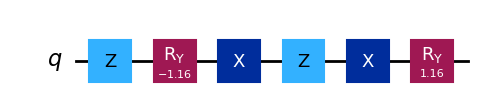

In [3]:
def build_S_psi0(n_qubits):
    qc = QuantumCircuit(n_qubits)
    qc.z(n_qubits - 1)  # objective qubit is the last one
    return qc

def build_S0(n_qubits):
    qc = QuantumCircuit(n_qubits)
    qc.x(range(n_qubits))
    if n_qubits == 1:
        qc.z(0)
    else:
        qc.h(n_qubits - 1)
        qc.mcx(list(range(n_qubits - 1)), n_qubits - 1)
        qc.h(n_qubits - 1)
    qc.x(range(n_qubits))
    return qc

def build_Q_manual(A_circuit):
    n = A_circuit.num_qubits
    qc = QuantumCircuit(n)
    qc.compose(build_S_psi0(n), inplace=True)
    qc.compose(A_circuit.inverse(), inplace=True)
    qc.compose(build_S0(n), inplace=True)
    qc.compose(A_circuit, inplace=True)
    return qc

Q_manual = build_Q_manual(qc_A)
Q_manual.draw('mpl')

### Verifying $Q$'s rotation property

Apply $QA|0\rangle$ and check that $P(1)$ matches $\sin^2(3\theta_a)$ — since $A|0\rangle$ itself sits at angle $\theta_a$, and $Q$ adds another $2\theta_a$.

In [4]:
qc_QA_manual = QuantumCircuit(1)
qc_QA_manual.compose(qc_A, inplace=True)
qc_QA_manual.compose(Q_manual, inplace=True)

sv_QA = Statevector(qc_QA_manual)
p1_after_Q = abs(sv_QA.data[1])**2
predicted_p1 = np.sin(3*theta_a_true)**2

print('P(1) after QA|0> (manual Q):', p1_after_Q)
print('Predicted from rotation theory sin^2(3*theta_a):', predicted_p1)
print('Match:', np.isclose(p1_after_Q, predicted_p1))

P(1) after QA|0> (manual Q): 0.972
Predicted from rotation theory sin^2(3*theta_a): 0.9720000000000002
Match: True


## Part 3: Comparing against the library's automatic $Q$

`EstimationProblem` builds $Q$ automatically from $A$ via `GroverOperator` when no `grover_operator` argument is given. Verify it matches the manual construction.

In [5]:
problem = EstimationProblem(state_preparation=qc_A, objective_qubits=[0])
Q_library = problem.grover_operator

qc_QA_library = QuantumCircuit(1)
qc_QA_library.compose(qc_A, inplace=True)
qc_QA_library.compose(Q_library, inplace=True)

sv_QA_lib = Statevector(qc_QA_library)
p1_library = abs(sv_QA_lib.data[1])**2

print('P(1) after QA|0> (library Q):', p1_library)
print('P(1) after QA|0> (manual Q): ', p1_after_Q)
print('Match:', np.isclose(p1_library, p1_after_Q))

P(1) after QA|0> (library Q): 0.9719999999999998
P(1) after QA|0> (manual Q):  0.972
Match: True


## Part 4: Running all three AE variants

- **`AmplitudeEstimation`** — canonical, QPE-based (control-qubit register + inverse QFT, exactly Notebook 1's machinery, applied to $Q$).
- **`IterativeAmplitudeEstimation`** — adaptive, no explicit QFT circuit; converges to a target precision/confidence.
- **`MaximumLikelihoodAmplitudeEstimation`** — repeated $Q^k$ applications plus classical maximum-likelihood fitting; this is the method Stamatopoulos et al. use for their real-hardware experiments (Section 5), since it needs far fewer gates than the canonical circuit.

In [6]:
sampler = StatevectorSampler()

ae = AmplitudeEstimation(num_eval_qubits=5, sampler=sampler)
result_ae = ae.estimate(problem)

iae = IterativeAmplitudeEstimation(epsilon_target=0.01, alpha=0.05, sampler=sampler)
result_iae = iae.estimate(problem)

mlae = MaximumLikelihoodAmplitudeEstimation(evaluation_schedule=4, sampler=sampler)
result_mlae = mlae.estimate(problem)

print(f'True a:                    {a_true}')
print(f'Canonical AE estimate:     {result_ae.estimation}')
print(f'Iterative AE estimate:     {result_iae.estimation}')
print(f'Maximum Likelihood AE:     {result_mlae.estimation}')

True a:                    0.3
Canonical AE estimate:     0.3086583
Iterative AE estimate:     0.3000924481834021
Maximum Likelihood AE:     0.29882095199612635


## Results Summary

- $A$, built as a single `RY` rotation, exactly encodes the chosen target probability $a=0.3$.
- $Q$, built manually from its two reflections, rotates by exactly $2\theta_a$
- The manually-built $Q$ and the library's automatically-constructed Grover operator agree exactly.
- All three AE algorithm variants recover $a\approx0.3$ on the noiseless simulator, with the expected precision/confidence tradeoffs of each method.

## What's Next

**Notebook 3** applies this exact AE machinery to a real financial problem: pricing a **vanilla European call option**. This introduces the two remaining building blocks — **distribution loading** (encoding a discretized probability distribution into $A$) and **payoff circuits** (comparators and controlled rotations, combining with distribution loading to build a complete $A$ whose measured probability equals the option's expected payoff).